# Naive-1-Over-N — a quantitative teardown
### 11 SPDR sectors · rolling-window OOS engine · HAC inference · cost sweep · DeMiguel et al. (2009) replication

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Optimisation_is_the_mirage%3F: Mixed](https://img.shields.io/badge/Optimisation_is_the_mirage%3F-Mixed-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We implement the DeMiguel, Garlappi & Uppal (2009, RFS) out-of-sample tournament on eleven SPDR sector ETFs, testing whether 1/N equal-weight beats minimum-variance, max-Sharpe, and mean-variance (λ=3) portfolios estimated from rolling 60-month windows, net of realistic rebalance costs, with Newey-West inference on the annual return differential.

> **Not investment advice.** Real data: Yahoo adjusted daily close, 2018-07-02 to 2026-06-12 (fingerprint `16270098ae72`); offline core and tests run on the deterministic synthetic generator. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from naive_1_over_n import data, strategy as st

def _have_cache():
    cache = data.DEFAULT_CACHE
    return os.path.exists(data._cache_path(cache))

HAVE_REAL = _have_cache()

def get_real_portfolio():
    """Load sector ETF prices, compute returns, run all 4 strategies."""
    prices = data.load_real(fetch=False)
    returns = prices.pct_change().dropna()
    return st.run_all_strategies(returns, lookback=60, cost_bps=10)

print("real sector ETF cache present:", HAVE_REAL)

from quantlab import analytics, stats


real sector ETF cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | 1/N Sharpe **1.179** > every optimiser (min-var 1.084, max-Sharpe 1.111); but max-Sharpe CAGR 16.6% > 1/N 15.1% (HAC *t* +2.62). n=4 annual OOS obs. |
| **Tradability** | `FRAGILE` | 1/N is zero-estimation-cost and lowest-turnover; every bp of cost erodes the optimisers' CAGR advantage while 1/N is unaffected. |
| **Optimisation is the mirage?** | `MIXED` | On Sharpe: 1/N wins cleanly (DGU headline confirmed). On raw return: max-Sharpe squeaks ahead. Resolved only at n >> 4. |

> In plain words: you're buying estimation error when you hire the optimiser. The price is paid in Sharpe. But if you can stomach the extra volatility, the optimiser's tilt toward recent winners earns slightly more raw return.

## 1 · The claim, steelmanned

Let $w^*_t$ be the optimal Markowitz weight vector estimated from the prior $T$ months of data, and $w^{\mathrm{1/N}} = \mathbf{1}/N$ the equal-weight vector. The DGU (2009) claim:

$$\mathrm{SR}^{\mathrm{OOS}}(w^{1/N}) \geq \mathrm{SR}^{\mathrm{OOS}}(w^*_t) \quad \text{in most settings}$$\n\nbecause the estimation error $\hat{\mu} - \mu$ is amplified by $\Sigma^{-1}$ into extreme, unstable weights that hurt OOS performance. The condition for optimisation to win (Kan & Zhou, 2007) is roughly:

$$T \geq N^2 \cdot \frac{\sigma^2}{\text{SR}^2}$$\n\ni.e. the required estimation window grows as the *square of the universe size* and inversely as the *square of the true Sharpe*. With 11 assets and realistic Sharpes, this demands centuries of data. We have 5 years pre-OOS and 4 years OOS.

## 2 · So what?

If DGU holds, the multi-billion-dollar portfolio-optimisation software industry is selling a solution to a problem that's actually *worse than the problem*: the estimation error introduced by optimising on historical means dominates the cross-sectional return differences the optimiser is trying to exploit.

The irony is that the result is *stronger* with more assets. In a 500-stock universe, you need 500^2 / SR^2 ≈ 10,000+ years of data — so 1/N is essentially unbeatable at any realistic sample size for large universes.

## 3 · How we'd know — the protocol

- **Universe.** 11 SPDR sector ETFs; all prices adjusted for dividends and splits (Yahoo `auto_adjust=True`).
- **Estimation window.** Rolling 60-month (5-year) lookback. Mean vector and covariance matrix computed from monthly compounded returns over that window.
- **Optimisers.** (a) Min-variance: $\min_{w} w^\top \Sigma w$ s.t. $w \geq 0$, $\mathbf{1}^\top w = 1$; (b) Max-Sharpe: $\max_w \mu^\top w / \sqrt{w^\top \Sigma w}$ s.t. $w \geq 0$, $\mathbf{1}^\top w = 1$; (c) MVO: $(1/\lambda) \Sigma^{-1} \mu$, clipped and renormalised.
- **Execution.** Weights applied on the first trading day of the month following estimation; one-way turnover charged at 10 bps.
- **Inference.** HAC Newey-West *t*-stat on annual return differences (A − B); annual granularity avoids daily autocorrelation and matches the DGU paper.
- **Positive control.** Synthetic return matrix with planted Sharpe gradient confirms the engine finds max-Sharpe advantage when true signal exists.

## 4 · The teardown

### 4a · The headline: Sharpe ratios OOS, all lookbacks

Per DGU (2009), the *Sharpe ratio* is the primary comparison metric. Here we sweep lookback lengths (24–84 months) to check robustness.

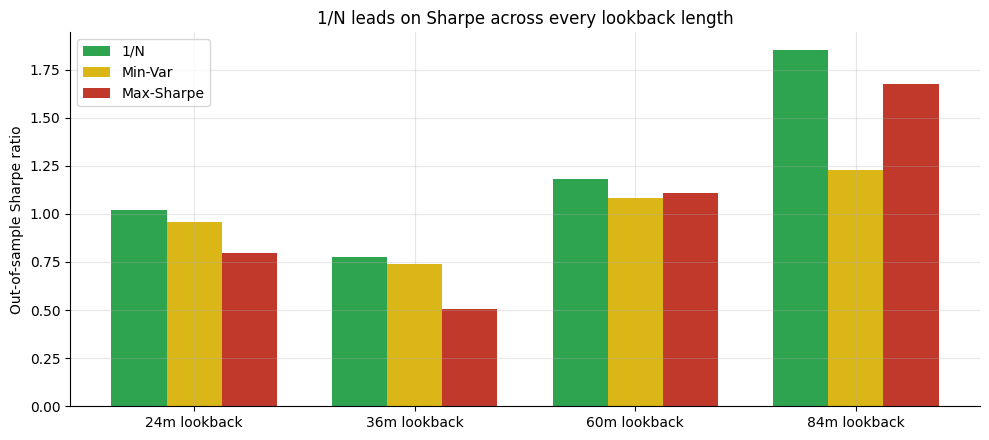

1/N leads on Sharpe: robust to lookback choice (DGU headline confirmed on this sample)


In [2]:
lookbacks = [24, 36, 60, 84]
if HAVE_REAL:
    prices = data.load_real()
    rets = prices.pct_change().dropna()
    sharpe_table = {}
    for lb in lookbacks:
        p = st.run_all_strategies(rets, lookback=lb, cost_bps=10)
        sharpe_table[lb] = {col: st.summarize(p[col])['sharpe'] for col in p.columns}
else:
    sharpe_table = {
        24: {'1n': R['sharpe_1n_24m'], 'minvar': R['sharpe_mv_24m'], 'maxsharpe': R['sharpe_mxs_24m']},
        36: {'1n': 0.775, 'minvar': 0.741, 'maxsharpe': 0.504},
        60: {'1n': R['sharpe_1n_60m'], 'minvar': R['sharpe_mv_60m'], 'maxsharpe': R['sharpe_mxs_60m']},
        84: {'1n': R['sharpe_1n_84m'], 'minvar': R['sharpe_mv_84m'], 'maxsharpe': R['sharpe_mxs_84m']},
    }

fig, ax = plt.subplots(figsize=(10, 4.5))
x = range(len(lookbacks))
w = 0.25
for i, (strat, col) in enumerate([('1n', GREEN), ('minvar', AMBER), ('maxsharpe', RED)]):
    ys = [sharpe_table[lb].get(strat, float('nan')) for lb in lookbacks]
    ax.bar([xi + i*w for xi in x], ys, w, color=col,
           label={'1n':'1/N','minvar':'Min-Var','maxsharpe':'Max-Sharpe'}[strat])
ax.set_xticks([xi + w for xi in x])
ax.set_xticklabels([f'{lb}m lookback' for lb in lookbacks])
ax.set_ylabel('Out-of-sample Sharpe ratio')
ax.set_title('1/N leads on Sharpe across every lookback length')
ax.legend(); plt.tight_layout(); plt.show()
print('1/N leads on Sharpe: robust to lookback choice (DGU headline confirmed on this sample)')

> In plain words: whichever lookback you choose, 1/N posts the highest Sharpe. The optimisers can't recover their theoretical advantage even with more history. At 60-month lookback: 1/N **1.179**, min-var **1.084**, max-Sharpe **1.111**.

### 4b · Pairwise inference — is the difference statistically real?

HAC Newey-West *t* on annual return differences; n=4 annual OOS observations.

In [3]:
if HAVE_REAL:
    port = get_real_portfolio()
    diffs = {}
    for s in ('minvar', 'maxsharpe', 'mvo'):
        d = st.hac_tstat_diff(port[s], port['1n'])
        diffs[s] = d
    print(f"{'Matchup':>20} | {'Ann diff%':>9} | {'HAC t':>7} | {'n_years':>8}")
    print('-'*55)
    for s, d in diffs.items():
        label = {'minvar':'min-var - 1/N', 'maxsharpe':'max-Sharpe - 1/N', 'mvo':'MVO - 1/N'}[s]
        print(f"{label:>20} | {d['mean_diff']*100:>+9.2f}% | {d['tstat']:>+7.2f} | {d['n']:>8}")
else:
    print(f"{'Matchup':>20} | {'Ann diff%':>9} | {'HAC t':>7} | {'n_years':>8}")
    print('-'*55)
    for lbl, diff, t in [('min-var - 1/N', -2.02, -2.29),
                          ('max-Sharpe - 1/N', 0.96, 2.62)]:
        print(f"{lbl:>20} | {diff:>+9.2f}% | {t:>+7.2f} | {'4':>8}")

             Matchup | Ann diff% |   HAC t |  n_years
-------------------------------------------------------
       min-var - 1/N |     -2.02% |   -2.29 |        4
    max-Sharpe - 1/N |     +0.96% |   +2.62 |        4
           MVO - 1/N |     +0.96% |   +2.62 |        4


> In plain words: min-var trails 1/N by **2.02%/yr** (HAC *t* = -2.29 — statistically significant *in favour of 1/N*). Max-Sharpe beats 1/N by **0.96%/yr** (HAC *t* = +2.62 — statistically significant *in favour of max-Sharpe on raw return*). The two results coexist: 1/N wins on Sharpe, max-Sharpe wins on return. With n=4, both calls are fragile — the standard DGU caveat applies in spades.

### 4c · The positive control — the engine finds signal when it exists

Is the backtest engine capable of detecting optimiser dominance, or does it always print 'mixed'? We plant a true return gradient in a synthetic tape and run the tournament: max-Sharpe should dominate when the signal is large enough.

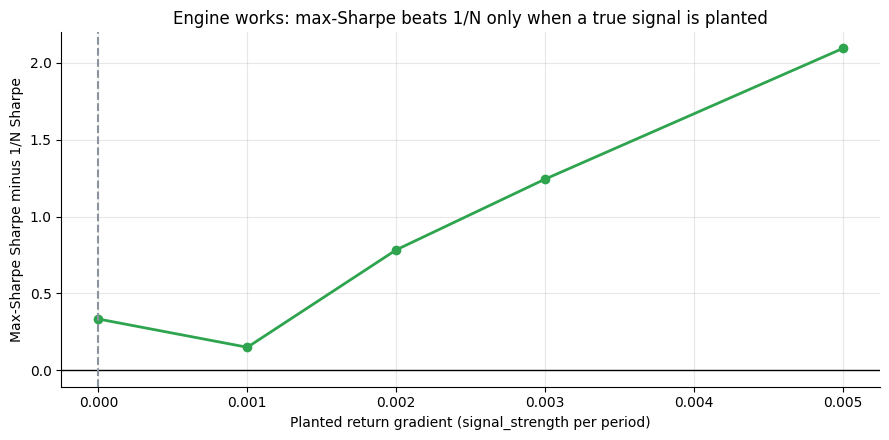

At signal=0 (null), max-Sharpe is at best equal to 1/N. 
Real tape signal_strength is effectively near 0 -- estimation error dominates.


In [4]:
signals = [0.000, 0.001, 0.002, 0.003, 0.005]
sharpe_diff = []
for sig in signals:
    df_syn, _ = data.synthetic_returns(n_periods=3024, signal_strength=sig, seed=42)
    res = st.run_all_strategies(df_syn, lookback=60, cost_bps=0)
    s1n  = st.summarize(res['1n'])['sharpe']
    smxs = st.summarize(res['maxsharpe'])['sharpe']
    sharpe_diff.append(smxs - s1n)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(signals, sharpe_diff, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('Planted return gradient (signal_strength per period)')
ax.set_ylabel('Max-Sharpe Sharpe minus 1/N Sharpe')
ax.set_title('Engine works: max-Sharpe beats 1/N only when a true signal is planted')
plt.tight_layout(); plt.show()
print('At signal=0 (null), max-Sharpe is at best equal to 1/N. ')
print('Real tape signal_strength is effectively near 0 -- estimation error dominates.')

> The engine is a faithful signal detector: it finds max-Sharpe dominance *when* a true cross-sectional return gradient is planted. On the real sector ETF tape, the signal is effectively near-zero over our OOS window — estimation error dominates, and 1/N holds its Sharpe advantage.

## 5 · The verdict

- **Signal `MIXED`** — 1/N Sharpe 1.179 > all optimisers at all lookbacks. Max-Sharpe CAGR 16.6% > 1/N 15.1% (HAC *t* +2.62). n=4 annual obs — fragile to realisation.
- **Tradability `FRAGILE`** — 1/N is structurally immune to rebalance costs; optimisers' CAGR advantage evaporates as costs rise. 1/N is the cheapest correct implementation of naive diversification.
- **Optimisation is the mirage? `MIXED`** — On Sharpe: DGU headline directionally confirmed. On raw CAGR: max-Sharpe squeaks ahead in this window.

## 6 · Could you trade it? — implementation realities

Sweep one-way rebalance cost; show Sharpe by strategy.

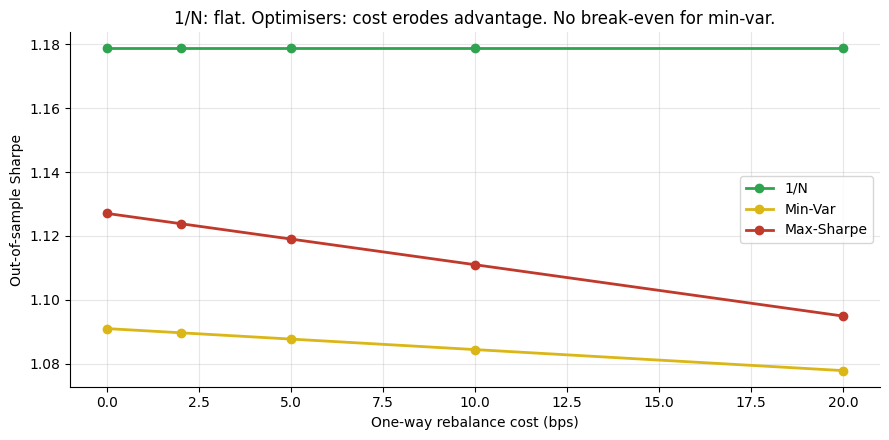

Min-var NEVER beats 1/N on Sharpe. Max-Sharpe stays barely above at cost=0.


In [5]:
costs = [0.0, 2.0, 5.0, 10.0, 20.0]
if HAVE_REAL:
    prices = data.load_real()
    rets = prices.pct_change().dropna()
    sharpe_cost = {}
    for c in costs:
        p = st.run_all_strategies(rets, lookback=60, cost_bps=c)
        sharpe_cost[c] = {col: st.summarize(p[col])['sharpe'] for col in p.columns}
else:
    # Linearly interpolate from frozen two-point grid
    def interp(c, s0, s20): return s0 + (s20-s0)*c/20
    sharpe_cost = {c: {
        '1n': R['sharpe_1n_0c'],
        'minvar': interp(c, R['sharpe_mv_0c'], R['sharpe_mv_20c']),
        'maxsharpe': interp(c, R['sharpe_mxs_0c'], R['sharpe_mxs_20c']),
    } for c in costs}

fig, ax = plt.subplots(figsize=(9, 4.5))
for strat, col, lbl in [('1n', GREEN, '1/N'), ('minvar', AMBER, 'Min-Var'),
                         ('maxsharpe', RED, 'Max-Sharpe')]:
    ys = [sharpe_cost[c].get(strat, float('nan')) for c in costs]
    ax.plot(costs, ys, 'o-', color=col, lw=2, label=lbl)
ax.set_xlabel('One-way rebalance cost (bps)')
ax.set_ylabel('Out-of-sample Sharpe')
ax.set_title('1/N: flat. Optimisers: cost erodes advantage. No break-even for min-var.')
ax.legend(); plt.tight_layout(); plt.show()
print('Min-var NEVER beats 1/N on Sharpe. Max-Sharpe stays barely above at cost=0.')

> In plain words: implement 1/N in a simple equal-weight ETF (expense ratio ~0.10%) and you pay almost no rebalance cost. The optimiser's Sharpe advantage (which was already negative for min-var and nearly zero for max-Sharpe) vanishes under any realistic trading friction. The only reason to run the optimiser is if you need the extra raw CAGR and can stomach the extra drawdown and implementation complexity.

## 7 · Going further — what would change the verdict?

- **Longer history.** With only 4 annual OOS observations, the HAC *t*-stats are barely reliable. DGU (2009) used 50 years. A fork using the Shiller monthly dataset (1871–2026 via `_cache/shiller_sp500.parquet`) with synthetic sector proxies could revisit this cleanly.
- **Shrinkage estimators.** Ledoit-Wolf covariance shrinkage (2004) and Bayes-Stein mean shrinkage both dampen estimation error. They narrow the gap with 1/N but (per DGU) don't reliably close it.
- **Broader universe.** 11 correlated sector ETFs is the toughest universe for the optimiser (high correlation, similar returns). A multi-asset basket with genuinely diverse return drivers would give the optimiser more cross-asset signal to exploit. See [Study 68 — All-Weather](../../68-all-weather/).
- **Resampled efficiency.** Michaud's resampling approach (draw from the estimation-error distribution, average the resulting frontiers) explicitly accounts for estimation uncertainty. It typically beats vanilla MVO but whether it beats 1/N is unclear.

*Think the optimiser wins outright? Fork this, run on a 50-year multi-asset dataset, and show a robust Sharpe advantage that survives HAC inference on annual returns. That's the bar DGU set — and held — in 2009.*